# 06. 逻辑斯蒂回归-分类

logistic regression

视频中截图
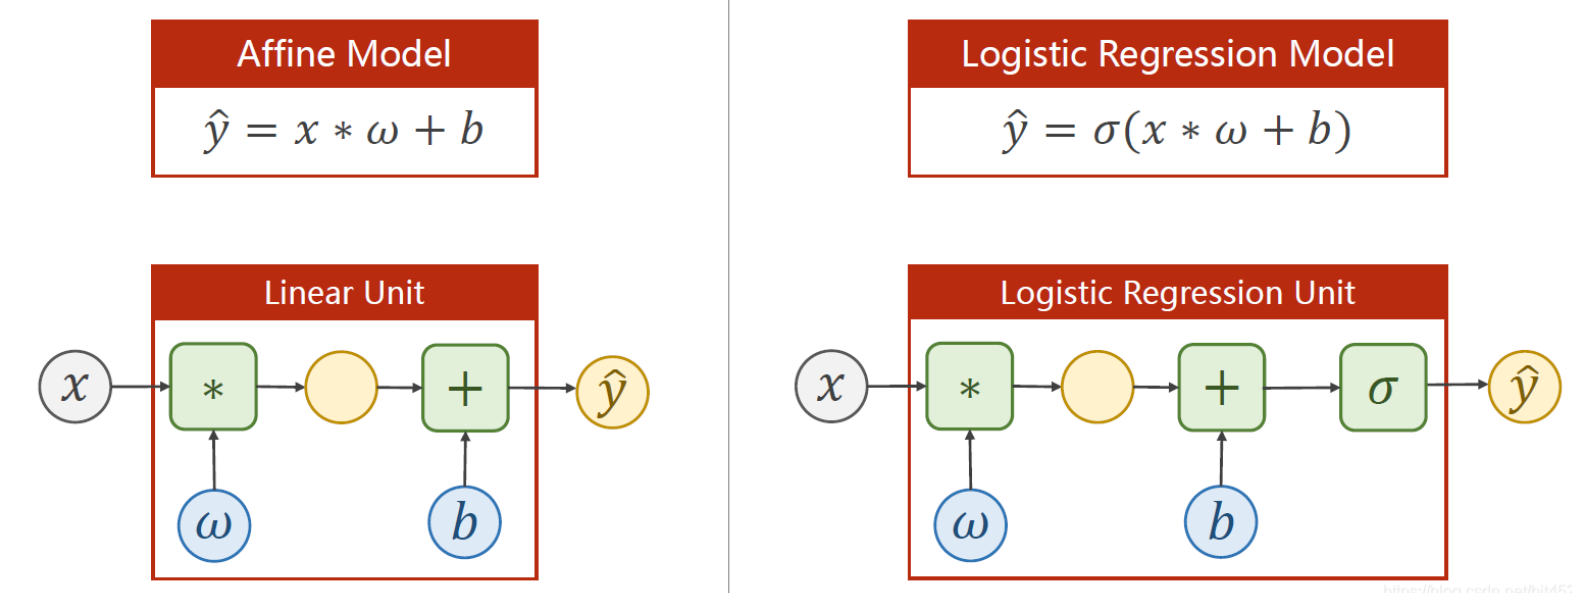


说明：1、 逻辑斯蒂回归和线性模型的明显区别是在线性模型的后面，添加了激活函数(非线性变换)

    2、分布的差异：KL散度，cross-entropy交叉熵

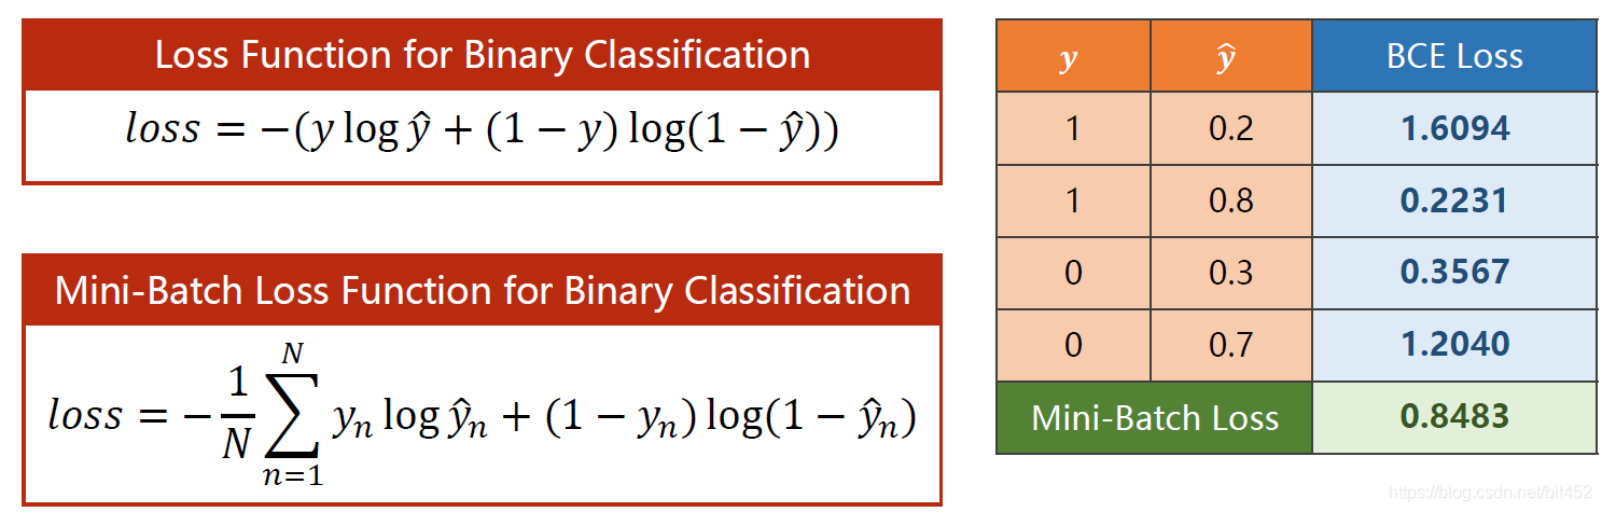

说明：预测与标签越接近，BCE损失越小。

代码说明：

1、视频中代码F.sigmoid(self.linear(x))会引发warning，此处更改为torch.sigmoid(self.linear(x))

     torch.sigmoid()、torch.nn.Sigmoid()和torch.nn.functional.sigmoid()三者之间的区别

2、BCELoss - Binary CrossEntropyLoss 

     BCELoss 是CrossEntropyLoss的一个特例，只用于二分类问题，而CrossEntropyLoss可以用于二分类，也可以用于多分类。

     如果是二分类问题，建议BCELoss



In [ ]:
import torch
# import torch.nn.functional as F
 
# prepare dataset
x_data = torch.Tensor([[1.0], [2.0], [3.0]])
y_data = torch.Tensor([[0], [0], [1]])
 
#design model using class
class LogisticRegressionModel(torch.nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(1,1)
 
    def forward(self, x):
        # y_pred = F.sigmoid(self.linear(x))
        y_pred = torch.sigmoid(self.linear(x))
        return y_pred
model = LogisticRegressionModel()
 
# construct loss and optimizer
# 默认情况下，loss会基于element平均，如果size_average=False的话，loss会被累加。
criterion = torch.nn.BCELoss(reduction='sum') 
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)
 
# training cycle forward, backward, update
for epoch in range(1000):
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)
    print(epoch, loss.item())
 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
 
print('w = ', model.linear.weight.item())
print('b = ', model.linear.bias.item())
 
x_test = torch.Tensor([[4.0]])
y_test = model(x_test)
print('y_pred = ', y_test.data)

0 2.5341620445251465
1 2.5312159061431885
2 2.528277635574341
3 2.5253467559814453
4 2.52242374420166
5 2.519508123397827
6 2.516599178314209
7 2.513697624206543
8 2.5108025074005127
9 2.5079145431518555
10 2.505032539367676
11 2.502157211303711
12 2.4992878437042236
13 2.496424913406372
14 2.493567943572998
15 2.4907169342041016
16 2.4878716468811035
17 2.485032081604004
18 2.482198715209961
19 2.479370594024658
20 2.476548194885254
21 2.473731517791748
22 2.4709200859069824
23 2.468114137649536
24 2.465313673019409
25 2.4625186920166016
26 2.459728479385376
27 2.4569437503814697
28 2.4541640281677246
29 2.451390027999878
30 2.4486207962036133
31 2.445856809616089
32 2.4430980682373047
33 2.4403440952301025
34 2.4375951290130615
35 2.4348514080047607
36 2.432112693786621
37 2.4293789863586426
38 2.426650047302246
39 2.4239258766174316
40 2.4212069511413574
41 2.4184930324554443
42 2.415783643722534
43 2.413079261779785
44 2.410379648208618
45 2.4076850414276123
46 2.4049952030181885
4

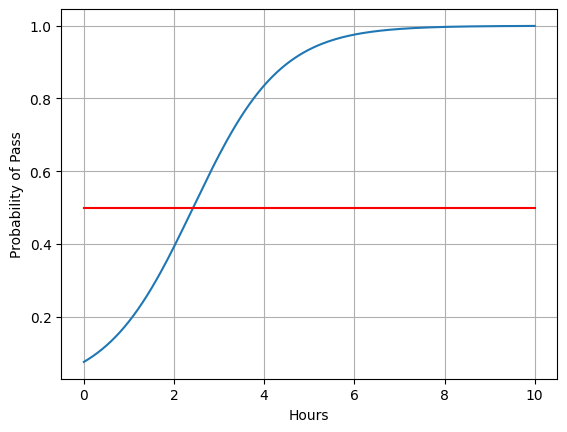

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 200)
x_t = torch.Tensor(x).view((200, 1)) #reshape,200行1列
y_t = model(x_t)
y = y_t.data.numpy()

plt.plot(x, y)
plt.plot([0, 10], [0.5, 0.5], c ='r') #color = red
plt.xlabel('Hours')
plt.ylabel('Probability of Pass')
plt.grid()
plt.show()